## Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Load the datasets

In [3]:
# Household data ()
household = pd.read_csv(r"C:\Users\dayan\Downloads\myfooddata\faps_household_puf.csv")
# Food at Home dataset (FAH)
fah = pd.read_csv(r"C:\Users\dayan\Downloads\myfooddata\faps_fahevent_puf.csv")
# Food Away from Home dataset (FAFH)    
fafh = pd.read_csv(r"C:\Users\dayan\Downloads\myfooddata\faps_fafhevent_puf.csv")

print("Household:", household.shape)
print("FAH:", fah.shape)
print("FAFH:", fafh.shape)


Household: (4826, 279)
FAH: (15998, 73)
FAFH: (39120, 82)


The analysis used three FoodAPS datasets: the household file, the Food-at-Home (FAH) event file, and the Food-Away-from-Home (FAFH) event file. The household dataset contained 4,826 households. Because households could report multiple food-purchase events, the FAH and FAFH event data were aggregated by household before being merged with the household dataset.

In [5]:
# Select variables of interest from the household dataset.
columns = [
    "hhnum",
    "nmealshome",
    "hhsize",
    "inchhavg_r",
    "ndinnersouthh"
]

df = household[columns].copy()

# Rename the variables for clarity.
df = df.rename(columns={
    "hhnum"         : "household_id",
    "nmealshome"    : "number_of_dinner_prepare_at_home",
    "hhsize"        : "household_size",
    "inchhavg_r"    : "monthly_household_income",
    "ndinnersouthh" : "dinner_eaten_out"
})


df.head()
df.shape


(4826, 5)

## Clean Special Survey Codes

In [6]:
for column in df.columns:
    if column != "hhnum":
        df.loc[df[column] < 0, column] = np.nan

df.isnull().sum()


household_id                           0
number_of_dinner_prepare_at_home       4
household_size                         0
monthly_household_income               0
dinner_eaten_out                    1010
dtype: int64

Negative survey response codes were treated as missing values rather than valid numeric observations. After cleaning, four households were missing information on dinners prepared at home. These observations were excluded from the final regression analysis, resulting in a sample of 4,822 households.

# Aggregate Food-at-Home Spending and Food-Away-from-Home spending

In [7]:
# Food at home spending by household aggregated by household id
fah_spending = (
    fah.groupby("hhnum")["totalpaid"]
       .sum(min_count=1)
       .reset_index()
)

fah_spending = fah_spending.rename(
    columns={
        "hhnum": "household_id",
        "totalpaid": "food_at_home_spending"}
)

fah_spending.head()

# Food away from home spending by household aggregated by household id

fafh_spending = (
    fafh.groupby("hhnum")["totalpaid"]
       .sum(min_count=1)
       .reset_index()
)

fafh_spending = fafh_spending.rename(
    columns={
        "hhnum": "household_id",
        "totalpaid": "food_away_from_home_spending"}
)


#  Merge the Data

In [8]:
df = df.merge(
    fah_spending,
    on="household_id",
    how="left"
)

df = df.merge(
    fafh_spending,
    on="household_id",
    how="left"
)

print(df.shape)
df.head()


(4826, 7)


,household_id,number_of_dinner_prepare_at_home,household_size,monthly_household_income,dinner_eaten_out,food_at_home_spending,food_away_from_home_spending
0,100012.0,9.0,5.0,4667.33,1.0,133.57,28.90
1,100015.0,5.0,1.0,1200.00,NaN,40.56,32.43
2,100024.0,3.0,2.0,5024.50,0.0,82.97,72.84
3,100026.0,7.0,2.0,1800.00,2.0,122.95,45.91
4,100028.0,7.0,7.0,3998.00,0.0,88.99,122.51


# Create Total Food Spending

In [9]:
# This engineered variable is the outcome (Y) for the basic regression.
df["total_food_spending"] = (
    df["food_at_home_spending"].fillna(0) +
    df["food_away_from_home_spending"].fillna(0)
)

df[[
    "household_id",
    "number_of_dinner_prepare_at_home",
    "food_at_home_spending",
    "food_away_from_home_spending",
    "total_food_spending"
]].head()


,household_id,number_of_dinner_prepare_at_home,food_at_home_spending,food_away_from_home_spending,total_food_spending
0,100012.0,9.0,133.57,28.90,162.47
1,100015.0,5.0,40.56,32.43,72.99
2,100024.0,3.0,82.97,72.84,155.81
3,100026.0,7.0,122.95,45.91,168.86
4,100028.0,7.0,88.99,122.51,211.50


# Prepare the Analysis Dataset

In [10]:
analysis_df = df[
    ["number_of_dinner_prepare_at_home", "total_food_spending"]
].dropna()

analysis_df.describe()


,number_of_dinner_prepare_at_home,total_food_spending
count,4822.000000,4822.000000
mean,5.229780,151.854023
std,2.607944,133.736838
min,0.000000,0.000000
25%,4.000000,59.975000
50%,5.000000,120.040000
75%,7.000000,208.287500
max,20.000000,2060.670000


# Exploratory Data Analysis (EDA)

# a- Summary Statistics

In [11]:
analysis_df.describe()

,number_of_dinner_prepare_at_home,total_food_spending
count,4822.000000,4822.000000
mean,5.229780,151.854023
std,2.607944,133.736838
min,0.000000,0.000000
25%,4.000000,59.975000
50%,5.000000,120.040000
75%,7.000000,208.287500
max,20.000000,2060.670000


Among the 4,822 households included in the analysis, the average number of dinners prepared at home was 5.23, with a median of 5. Average total food spending was approximately $151.85, while median spending was $120.04. The higher mean relative to the median and the maximum spending value of $2,060.67 indicate that the spending distribution contains several high-spending observations.

# b- Distribution of home dinner preparation

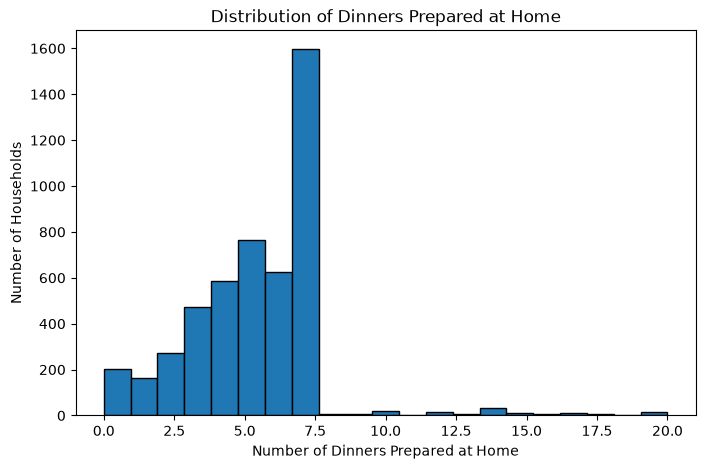

In [58]:
plt.figure(figsize=(8, 5))
plt.hist(analysis_df["number_of_dinner_prepare_at_home"], bins=21, edgecolor="black")
plt.xlabel("Number of Dinners Prepared at Home")
plt.ylabel("Number of Households")
plt.title("Distribution of Dinners Prepared at Home")
plt.show()


The histogram shows that most households reported preparing dinner at home several times during the observation period, with observations concentrated around the middle-to-upper portion of the distribution. A relatively small number of households reported much higher values. These high values should be interpreted according to the FoodAPS coding definition for the variable.

# c- Scatterplot of the two regression variables

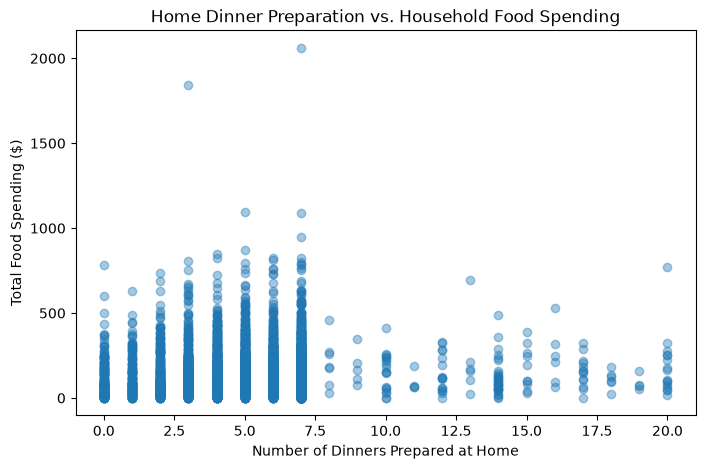

In [59]:
plt.figure(figsize=(8, 5))
plt.scatter(
    analysis_df["number_of_dinner_prepare_at_home"],
    analysis_df["total_food_spending"],
    alpha=0.4
)
plt.xlabel("Number of Dinners Prepared at Home")
plt.ylabel("Total Food Spending ($)")
plt.title("Home Dinner Preparation vs. Household Food Spending")
plt.show()

The scatterplot does not show a strong linear relationship between the number of dinners prepared at home and total food spending. Households with similar dinner-preparation frequencies display a wide range of food-spending amounts. Several high-spending observations are also visible, indicating substantial variation in household food spending.

# d- Correlation

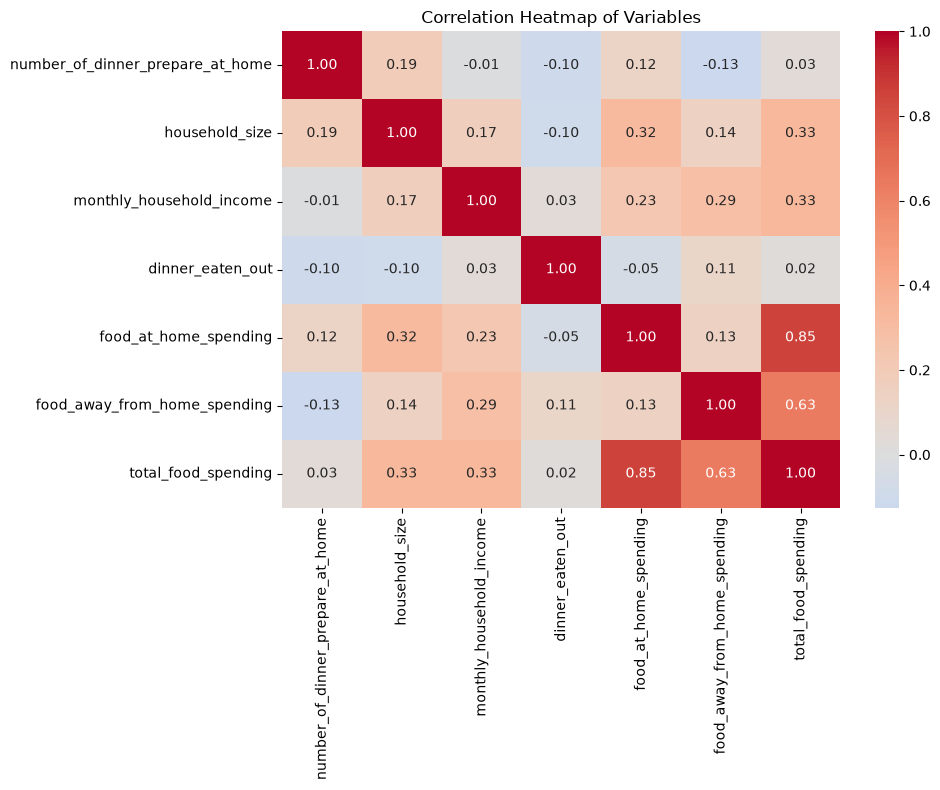

In [62]:
correlation_variables = df[[
    "number_of_dinner_prepare_at_home",
    "household_size",
    "monthly_household_income",
    "dinner_eaten_out",
    "food_at_home_spending",
    "food_away_from_home_spending",
    "total_food_spending"
]]

correlation_matrix = correlation_variables.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",center = 0)
plt.title("Correlation Heatmap of Variables")
plt.tight_layout()
plt.show()



r=0.03 which is extremely weak and close to zero. So:There is almost no linear relationship between how frequently households prepare dinner at home and their total food spending.
Although the relationship between home dinner preparation and total food spending was very weak (r = 0.03), the heatmap revealed small relationships with the components of spending. Dinner preparation at home was positively correlated with food-at-home spending (r = 0.12) and negatively correlated with food-away-from-home spending (r = −0.13). This suggests that more frequent home dinner preparation may be associated with where households spend their food dollars rather than with a substantial change in total food spending.

# d- Run the Basic Linear Regression

In [20]:
X = analysis_df[["number_of_dinner_prepare_at_home"]]
y = analysis_df["total_food_spending"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R-squared:", model.score(X, y))

Intercept: 143.02576846494654
Coefficient: 1.6880737751617003
R-squared: 0.001083620291339682


**Intercept = \$143.03:** so a household reporting zero dinners prepared at home is predicted by the model to have approximately \$143.03 in total food spending.

**Coefficient = +\$1.69:** this means, for each additional dinner prepared at home, the model predicts approximately \$1.69 higher total food spending, on average.Each additional dinner prepared at home was associated with approximately \$1.69 higher total food spending in the simple linear regression.

The regression produced an R² of approximately 0.0011, indicating that dinner preparation frequency explained only about 0.11% of the observed variation in total household food spending. Therefore, dinner preparation frequency alone has very little explanatory power for predicting total food spending in this sample.

# Conclusion
The analysis found very little evidence of a meaningful linear association between the frequency of preparing dinner at home and total household food spending. The correlation between the two variables was approximately 0.03, indicating an extremely weak positive relationship. The simple linear regression estimated that each additional dinner prepared at home was associated with approximately $1.69 higher total food spending. However, the model's R² was only 0.0011, meaning dinner preparation frequency explained approximately 0.11% of the variation in household food spending. Therefore, dinner preparation frequency alone does not appear to be a useful predictor of total food spending in this sample. Other household characteristics, such as household size and income, may play a more important role in explaining differences in food spending.

## Basic Multiple Linear Regression

In [69]:

multiple_df = df[
    [
        "number_of_dinner_prepare_at_home",
        "household_size",
        "monthly_household_income",
        "total_food_spending"
    ]
].dropna()

multiple_df.head()

X_multi = multiple_df[
    [
        "number_of_dinner_prepare_at_home",
        "household_size",
        "monthly_household_income"
    ]
]

y_multi = multiple_df["total_food_spending"]

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

print("Intercept:", multi_model.intercept_)

for variable, coefficient in zip(X_multi.columns, multi_model.coef_):
    print(variable, ":", coefficient)

print("R-squared:", multi_model.score(X_multi, y_multi))

Intercept: 52.629837879676415
number_of_dinner_prepare_at_home : -0.9706896866823101
household_size : 22.56023171557278
monthly_household_income : 0.010077329796029488
R-squared: 0.18731965873395784


The multiple linear regression showed that, after controlling for household size and monthly household income, the number of dinners prepared at home had only a very small negative association with total food spending. Each additional dinner prepared at home was associated with approximately *$0.97* lower total food spending. In contrast, household size had a stronger relationship with spending, with each additional household member associated with about $22.56 higher food spending. Monthly household income was also positively associated with spending, with each additional $1,000 in monthly income associated with approximately $10.07 higher food spending. The model had an R² of 0.1873, indicating that these three variables together explained about 18.7% of the variation in total food spending.